Fit window: 18-45 ns (55 bins)
T1 = 5.697 +/- 0.419 ns (approximate 1-sigma uncertainty)
Background = 3.190 counts/bin


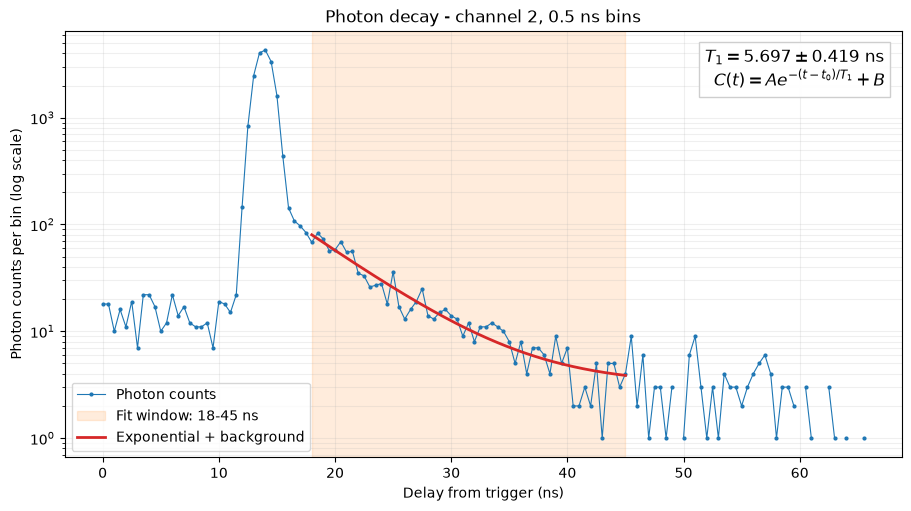

In [10]:
# Edit these limits (ns), then rerun this cell.
fit_start_ns = 18
fit_end_ns = 45.0

from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.special import xlogy


file_path = Path(r"C:\Users\yy3\qudi\Data\2026\09\2026-09-21\timetaggerlogic\20260921-1441-50_hist_data_trace_TEST.dat")
counts = np.loadtxt(file_path)
header = file_path.read_text()
bin_width_ns = float(re.search(r"^# bin width=(.+)$", header, re.MULTILINE).group(1)) * 1e9
delay_ns = np.arange(counts.size) * bin_width_ns

if not np.isfinite([fit_start_ns, fit_end_ns]).all() or not (
    delay_ns[0] <= fit_start_ns < fit_end_ns <= delay_ns[-1]
):
    raise ValueError(f"Choose 0 <= fit_start_ns < fit_end_ns <= {delay_ns[-1]:g} ns.")
if not np.isfinite(counts).all() or (counts < 0).any():
    raise ValueError("Counts must be finite and nonnegative.")
fit_mask = (delay_ns >= fit_start_ns) & (delay_ns <= fit_end_ns)
x_fit = delay_ns[fit_mask] - fit_start_ns
y_fit = counts[fit_mask]
if y_fit.size < 5 or y_fit.sum() == 0:
    raise ValueError("The fit window must contain at least five bins and nonzero counts.")

# A is the exponential amplitude at the start of the selected window.
# Fit raw counts with Poisson statistics, including zero-count bins.
def decay(t, amplitude, t1_ns, background):
    return amplitude * np.exp(-t / t1_ns) + background

def poisson_residuals(parameters):
    expected = np.maximum(decay(x_fit, *parameters), 1e-12)
    deviance = 2 * (xlogy(y_fit, y_fit / expected) - y_fit + expected)
    return np.sign(expected - y_fit) * np.sqrt(np.maximum(deviance, 0))

background_guess = max(float(np.mean(y_fit[-max(3, y_fit.size // 10):])), 0.1)
initial = [max(float(y_fit.max()) - background_guess, 1),
           (fit_end_ns - fit_start_ns) / 5, background_guess]
fit_result = least_squares(poisson_residuals, initial,
                           bounds=([0, 1e-6, 0], [np.inf, np.inf, np.inf]),
                           x_scale='jac', max_nfev=10000)
if not fit_result.success:
    raise RuntimeError(f"Decay fit failed: {fit_result.message}")
amplitude, t1_ns, background = fit_result.x

# Approximate 1-sigma uncertainty from the Poisson Fisher information.
expected = decay(x_fit, amplitude, t1_ns, background)
exponential = np.exp(-x_fit / t1_ns)
jacobian = np.column_stack((exponential,
    amplitude * exponential * x_fit / t1_ns**2, np.ones_like(x_fit)))
fisher = jacobian.T @ (jacobian / np.maximum(expected[:, None], 1e-12))
if np.linalg.matrix_rank(fisher) < 3:
    raise RuntimeError("This window does not constrain T1; choose a wider decay interval.")
covariance = np.linalg.inv(fisher)
t1_error_ns = np.sqrt(covariance[1, 1])
print(f"Fit window: {fit_start_ns:g}-{fit_end_ns:g} ns ({y_fit.size} bins)")
print(f"T1 = {t1_ns:.3f} +/- {t1_error_ns:.3f} ns (approximate 1-sigma uncertainty)")
print(f"Background = {background:.3f} counts/bin")

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
ax.semilogy(delay_ns, np.where(counts > 0, counts, np.nan), '.-',
            linewidth=0.8, markersize=4, color='tab:blue', label='Photon counts')
ax.axvspan(fit_start_ns, fit_end_ns, color='tab:orange', alpha=0.14,
           label=f'Fit window: {fit_start_ns:g}-{fit_end_ns:g} ns')
fit_time = np.linspace(fit_start_ns, fit_end_ns, 500)
ax.plot(fit_time, decay(fit_time - fit_start_ns, *fit_result.x),
        color='tab:red', linewidth=2, label='Exponential + background')
ax.text(0.98, 0.96,
        rf'$T_1 = {t1_ns:.3f} \pm {t1_error_ns:.3f}\ \mathrm{{ns}}$'
        + '\n' + rf'$C(t)=A e^{{-(t-t_0)/T_1}}+B$',
        transform=ax.transAxes, ha='right', va='top', fontsize=12,
        bbox=dict(facecolor='white', edgecolor='0.8', alpha=0.95))
ax.set_xlabel('Delay from trigger (ns)')
ax.set_ylabel('Photon counts per bin (log scale)')
ax.set_title(f'Photon decay - channel 2, {bin_width_ns:g} ns bins')
ax.grid(True, which='both', alpha=0.2)
ax.legend(loc='lower left')
plt.show()


In [ ]:
# Run the fit cell above first. Show only the fitted interval on a linear axis.
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
ax.plot(delay_ns[fit_mask], y_fit, '.-', linewidth=0.8, markersize=4,
        color='tab:blue', label='Photon counts')
fit_time = np.linspace(fit_start_ns, fit_end_ns, 500)
ax.plot(fit_time, decay(fit_time - fit_start_ns, *fit_result.x),
        color='tab:red', linewidth=2, label='Exponential + background')
ax.text(0.98, 0.96,
        rf'$T_1 = {t1_ns:.3f} \pm {t1_error_ns:.3f}\ \mathrm{{ns}}$',
        transform=ax.transAxes, ha='right', va='top', fontsize=12,
        bbox=dict(facecolor='white', edgecolor='0.8', alpha=0.95))
ax.set_xlim(fit_start_ns, fit_end_ns)
ax.set_yscale('linear')
ax.set_xlabel('Delay from trigger (ns)')
ax.set_ylabel('Photon counts per bin')
ax.set_title(f'Photon decay fit - channel 2, {bin_width_ns:g} ns bins')
ax.grid(True, alpha=0.2)
ax.legend(loc='lower left')
plt.show()
